In [50]:
# ======================================================
# Project #4: Visual Place Recognition using CNN (ResNet18)
# ======================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torchvision.models as models
import torchvision.transforms as T
from sklearn.metrics import precision_recall_curve, auc
from sklearn.decomposition import PCA
import seaborn as sns

# ---------------- CONFIGURATION ----------------
KITTI_IMAGES = "/Users/mayuri/Downloads/dataset/sequences/00/image_0"
KITTI_POSES = "/Users/mayuri/Downloads/dataset 2/poses/00.txt"  # ground truth
N_IMAGES = 4541
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RESIZE_TO = (640, 192)
REVISIT_THRESHOLD = 50.0  # meters
SKIP_NEAR = 20            # frames to avoid near duplicates
TOP_K = 50                # top matches per frame

# ======================================================
# 1. Load and Preprocess Images
# ======================================================
def load_images(path, n):
    files = sorted(os.listdir(path))[:n]
    imgs = []
    for f in files:
        img = cv2.imread(os.path.join(path, f))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        imgs.append(gray)
    return imgs, files

def preprocess(img):
    img = cv2.resize(img, RESIZE_TO)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    img = cv2.GaussianBlur(img, (3,3), 0)
    return img

def preprocess_all(images):
    return [preprocess(img) for img in tqdm(images, desc="Preprocessing images")]



In [51]:
# ======================================================
# 2. CNN (ResNet18) Feature Extraction
# ======================================================
def extract_resnet18_features(images):
    print("🔍 Extracting CNN features (ResNet18)...")
    model = models.resnet18(pretrained=True)
    model = torch.nn.Sequential(*list(model.children())[:-1])  # remove classifier
    model = model.to(DEVICE)
    model.eval()

    transform = T.Compose([
        T.ToPILImage(),
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
    ])

    feats = []
    with torch.no_grad():
        for img in tqdm(images):
            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            tensor = transform(img_rgb).unsqueeze(0).to(DEVICE)
            feat = model(tensor).squeeze().cpu().numpy()
            feat /= np.linalg.norm(feat) + 1e-8
            feats.append(feat)
    return np.array(feats)


In [52]:
# ======================================================
# 3. Dimensionality Reduction (PCA)
# ======================================================
def reduce_dim(features, dims=512):
    print("⚙️ Applying PCA reduction...")
    pca = PCA(n_components=dims, random_state=0)
    reduced = pca.fit_transform(features)
    reduced /= np.linalg.norm(reduced, axis=1, keepdims=True) + 1e-8
    return reduced

In [53]:
# ======================================================
# 4. Ground Truth Poses
# ======================================================
def load_poses(pose_file, n):
    if not os.path.exists(pose_file):
        raise FileNotFoundError(f"❌ Pose file not found: {pose_file}")
    poses = np.loadtxt(pose_file)[:n, [3, 7, 11]]  # extract x, y, z
    print(f"✅ Loaded {len(poses)} poses from KITTI ground truth.")
    return poses

def is_revisit(i, j, poses, threshold=REVISIT_THRESHOLD):
    dist = np.linalg.norm(poses[i] - poses[j])
    return dist < threshold


In [54]:
# ======================================================
# 5. Compute Similarity Matrix
# ======================================================
def compute_similarity(features):
    print("🔗 Computing pairwise similarities...")
    features = features / (np.linalg.norm(features, axis=1, keepdims=True) + 1e-8)
    sim = np.dot(features, features.T)
    np.fill_diagonal(sim, 0)
    return sim


In [55]:
# ======================================================
# 6. Evaluation: Confusion Matrix + AUC
# ======================================================
def evaluate(similarity, poses, top_k=TOP_K):
    y_true, y_score = [], []
    n = len(similarity)
    TP = FP = FN = 0

    # Collect ground truth and similarity scores
    for i in range(n):
        for j in range(i + SKIP_NEAR, n):
            y_score.append(similarity[i, j])
            y_true.append(1 if is_revisit(i, j, poses) else 0)

    # Compute PR curve and AUC
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_true, y_score)
    auc_score = auc(recall_curve, precision_curve)

    # Confusion matrix estimation (using threshold at top-k per frame)
    TP, FP, FN = 0, 0, 0
    for i in range(n):
        top_indices = np.argsort(similarity[i])[-top_k:]
        for j in top_indices:
            if j <= i + SKIP_NEAR:
                continue
            if is_revisit(i, j, poses):
                TP += 1
            else:
                FP += 1
        # Count false negatives (true revisits not detected)
        for j in range(i + SKIP_NEAR, n):
            if is_revisit(i, j, poses) and j not in top_indices:
                FN += 1

    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)

    print(f"\n=== Evaluation Results ===")
    print(f"True Positives: {TP}")
    print(f"False Positives: {FP}")
    print(f"False Negatives: {FN}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"AUC (Precision–Recall): {auc_score*100:.2f}%")

    return precision_curve, recall_curve, auc_score, TP, FP, FN, precision, recall


In [56]:
# ======================================================
# 7. Visualization
# ======================================================
def visualize_samples(images):
    fig, axs = plt.subplots(1, 4, figsize=(14, 4))
    for i, ax in enumerate(axs):
        ax.imshow(images[i], cmap='gray')
        ax.set_title(f"Frame {i}")
        ax.axis('off')
    plt.suptitle("Sample Preprocessed Images from KITTI Sequence 00")
    plt.show()

def visualize_similarity_matrix(sim):
    plt.figure(figsize=(7,6))
    sns.heatmap(sim, cmap='hot', cbar=True)
    plt.title("Similarity Matrix (Cosine Similarity)")
    plt.xlabel("Frame Index")
    plt.ylabel("Frame Index")
    plt.show()

def plot_pr_curve(precision, recall, auc_score):
    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, label=f"AUC = {auc_score:.3f}", linewidth=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve for Place Recognition")
    plt.legend()
    plt.grid(True)
    plt.show()

def visualize_top_matches(similarity, top_k=TOP_K):
    n = similarity.shape[0]
    revisit_matrix = np.zeros_like(similarity)
    for i in range(n):
        top_indices = np.argsort(similarity[i])[-top_k:]
        revisit_matrix[i, top_indices] = 1
    plt.figure(figsize=(7,6))
    sns.heatmap(revisit_matrix, cmap="Blues", cbar=False)
    plt.title(f"Top-{top_k} Match Heatmap (Revisit Detection)")
    plt.xlabel("Matched Frame Index")
    plt.ylabel("Query Frame Index")
    plt.show()


📂 Loading KITTI images...
52 46
52 46
🧼 Preprocessing...


Preprocessing images: 100%|██████████| 4541/4541 [00:01<00:00, 2461.05it/s]


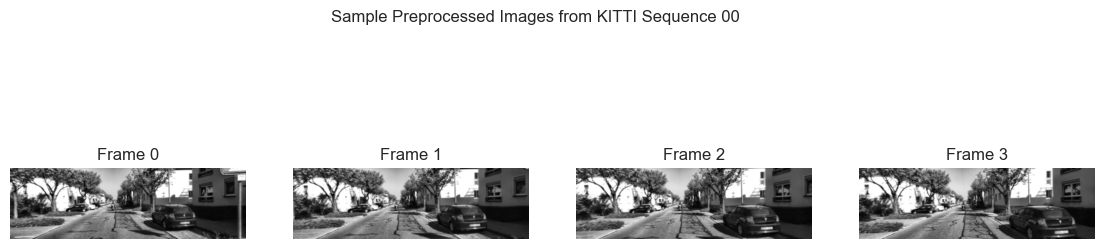

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🚀 Extracting CNN descriptors...
🔍 Extracting CNN features (ResNet18)...


100%|██████████| 4541/4541 [01:20<00:00, 56.68it/s]


⚙️ Applying PCA reduction...
📡 Loading ground-truth poses...
✅ Loaded 4541 poses from KITTI ground truth.
📊 Computing similarity and evaluation...
🔗 Computing pairwise similarities...


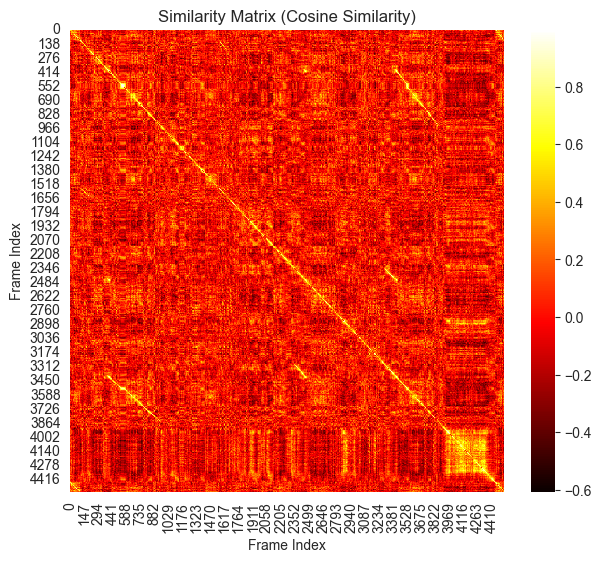


=== Evaluation Results ===
True Positives: 17353
False Positives: 59324
False Negatives: 194379
Precision: 0.2263
Recall: 0.0820
AUC (Precision–Recall): 11.52%


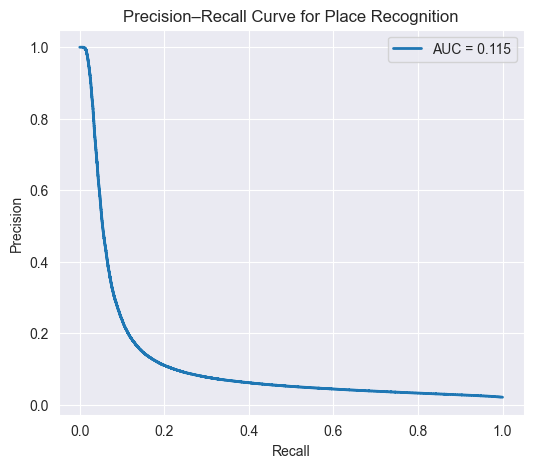

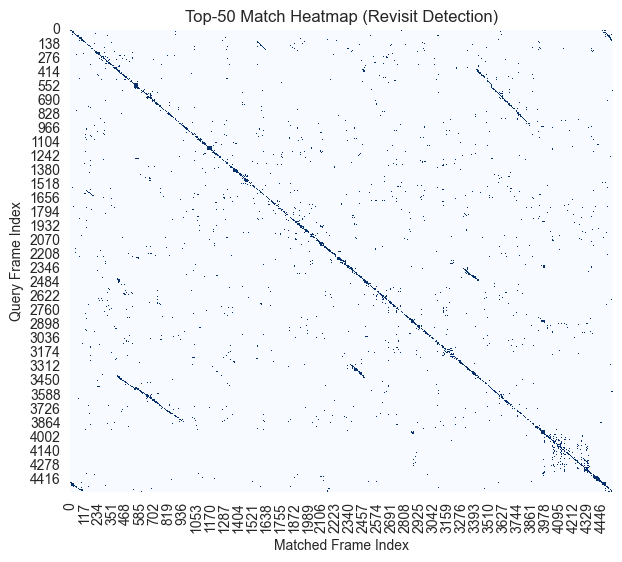


🎯 Place Recognition Evaluation Complete!


In [58]:
# ======================================================
# MAIN EXECUTION
# ======================================================
if __name__ == "__main__":
    print("📂 Loading KITTI images...")
    images, _ = load_images(KITTI_IMAGES, N_IMAGES)
    print(len(KITTI_IMAGES), len(KITTI_POSES))
    
    print("🧼 Preprocessing...")
    preproc = preprocess_all(images)
    visualize_samples(preproc[:4])

    print("🚀 Extracting CNN descriptors...")
    features = extract_resnet18_features(preproc)
    features_pca = reduce_dim(features, dims=128)

    print("📡 Loading ground-truth poses...")
    poses = load_poses(KITTI_POSES, N_IMAGES)

    print("📊 Computing similarity and evaluation...")
    sim_matrix = compute_similarity(features_pca)
    visualize_similarity_matrix(sim_matrix)

    precision_curve, recall_curve, auc_score, TP, FP, FN, precision, recall = evaluate(sim_matrix, poses, top_k=TOP_K)
    plot_pr_curve(precision_curve, recall_curve, auc_score)
    visualize_top_matches(sim_matrix, top_k=TOP_K)

    print("\n🎯 Place Recognition Evaluation Complete!")